In [1]:
import numpy as np
from matplotlib import pyplot as plt

import sklearn
import urllib.request

In [2]:
from astroML.datasets import generate_mu_z
from sklearn.gaussian_process import GaussianProcessRegressor, kernels
from scipy.optimize import fmin_cobyla
from sklearn.gaussian_process.kernels import ConstantKernel, RBF

In [3]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_predict

from sklearn.neighbors import KernelDensity
from astroML.linear_model import NadarayaWatson

/home/elisa/miniconda3/envs/fermipy/lib/python3.9/site-packages/astroML/linear_model/linear_regression_errors.py:10: UserWarning: LinearRegressionwithErrors requires PyMC3 to be installed
  warnings.warn('LinearRegressionwithErrors requires PyMC3 to be installed')


(35.0, 50.0)

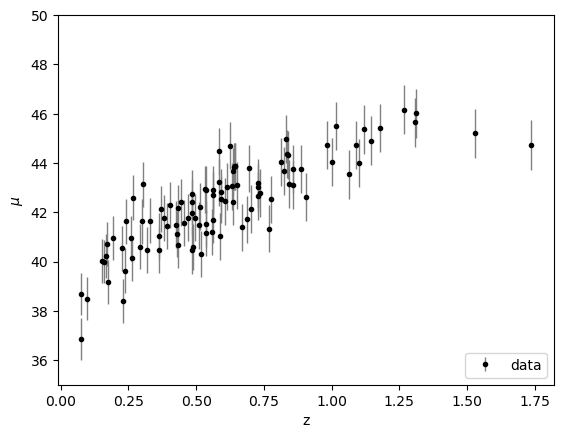

In [4]:
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) ###YOU CAN'T CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.ylim(35,50)

In [5]:
X = z_sample[:, np.newaxis]
y = mu_sample
dy = dmu

In [6]:
from sklearn.gaussian_process import GaussianProcessRegressor

#w/ default kernel

gp = GaussianProcessRegressor()
gp.fit(X,y)

linx = np.linspace(min(z_sample),max(z_sample),1000)[:, np.newaxis]
y_predx, dy_predx = gp.predict(linx, return_std=True)

In [7]:
gp3 = GaussianProcessRegressor()
gp3.fit(X,y)
y_pred, dy_pred = gp3.predict(X, return_std=True)
y_predx, dy_predx = gp3.predict(linx, return_std=True)

In [8]:
# Constrain the mean and covariance

dy3 = dy

kernel3 = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(10, (1e-2, 1e2)) # Radial-basis function kernel (aka squared-exponential kernel)
gp3 = GaussianProcessRegressor(kernel=kernel3,
                               alpha=dy3**2,
                               random_state=0)
gp3.fit(X,y)

linx = np.linspace(min(z_sample),max(z_sample),1000)[:, np.newaxis]
y_pred, dy_pred = gp3.predict(X, return_std=True)
y_predx, dy_predx = gp3.predict(linx, return_std=True)

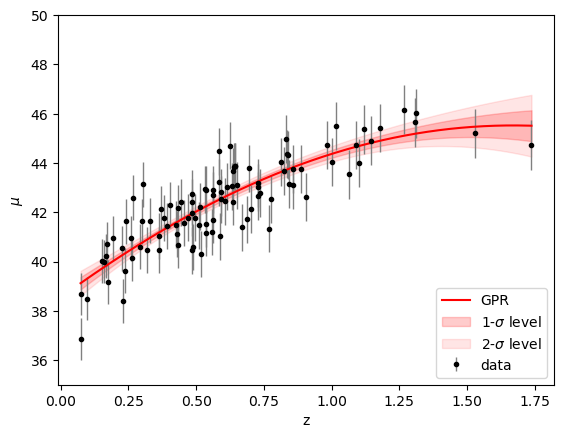

In [9]:
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
#plt.errorbar(z_sample, y_pred, dy_pred, fmt='.r', ecolor='gray', lw=1,label='GPR')
plt.plot(linx, y_predx, color='r', label='GPR')

plt.fill_between(linx[:,0], y_predx - dy_predx, y_predx + dy_predx, color='r', alpha=0.2, label='1-$\sigma$ level')
plt.fill_between(linx[:,0], y_predx - 2*dy_predx, y_predx + 2*dy_predx, color='r', alpha=0.1, label='2-$\sigma$ level')

plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.ylim(35,50);

(35.0, 50.0)

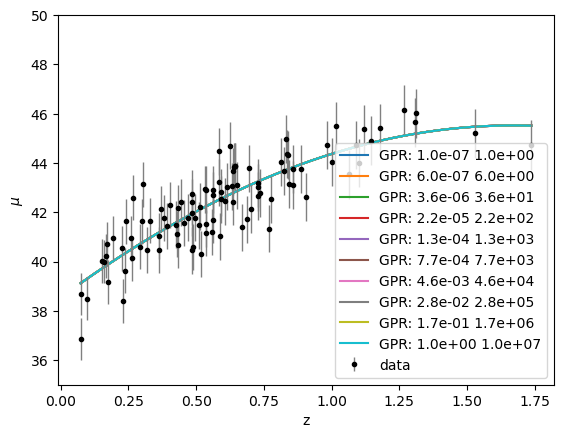

In [10]:
# Constrain the mean and covariance with many noisy points

dy3 = dy
lscales = np.logspace(-4,3,10)
gps = []
for ls in lscales:

    kernel3 = ConstantKernel(1.0, (1e-3, 1e3))*kernels.RBF(ls, (ls/1000, ls*40000))
    gp4 = GaussianProcessRegressor(kernel=kernel3,
                                   alpha=dy3**2,
                                   random_state=0)
    gps = np.append(gps, gp4)
    gp4.fit(X,y)
    y_predx, dy_predx = gp4.predict(linx, return_std=True)
    
    
    plt.plot(linx, y_predx, label='GPR: %.1e %.1e' % (ls/1000, ls*10000)  )

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')

plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.ylim(35,50)

In [11]:
# I should cross validate to find the best kernel 
# When the upper limit is too low the optimal value found for dimension 0 of parameter k2_length_scale is the upper limit
# Similarly when the lower limit is too high
# --> this problem is solved for upper limits always > 4 and 

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_validation, ydy_train, ydy_validation = train_test_split(X, np.array([y,dy]).T, test_size=0.3, random_state=42)
y_train,dy_train = ydy_train.T
y_validation,dy_validation = ydy_validation.T

In [13]:
def geterror(X,y,classifier):
    return np.sqrt( np.sum(( y - classifier.predict(X) )**2) / len(X) )

def fitanderror(classifier):
    classifier.fit(X_train, y_train)
    error_train = geterror(X_train,y_train,classifier)
    error_validation  = geterror(X_validation, y_validation, classifier)
    return error_train, error_validation

In [14]:
etrain, etest= [], []

for i, gpi in zip(lscales, gps):

    # Update alpha to match the training data's noise variance
    gpi.alpha = dy_train**2
    
    error_train, error_validation = fitanderror(gpi)
    etrain.append(error_train)
    etest.append(error_validation)


best_gpr_ind = np.argmin(etest)
print("Best", lscales[np.argmin(etest)], min(etest))

Best 0.774263682681127 0.8277053250152497


In [15]:
y_pred, dy_pred = gps[best_gpr_ind].predict(X, return_std=True)
y_predx, dy_predx = gps[best_gpr_ind].predict(linx, return_std=True)

(35.0, 50.0)

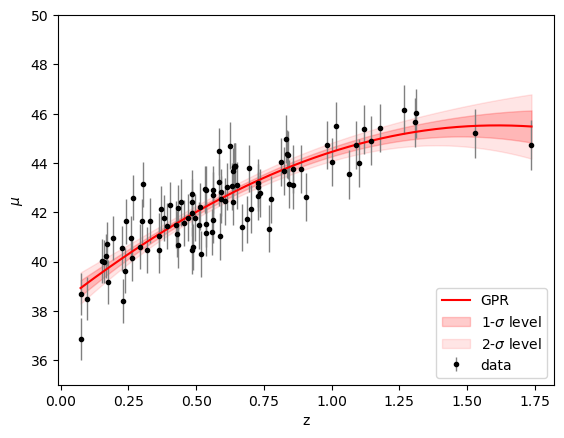

In [16]:
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
#plt.errorbar(z_sample, y_pred, dy_pred, fmt='.r', ecolor='gray', lw=1,label='GPR')
plt.plot(linx, y_predx, color='r', label='GPR')

plt.fill_between(linx[:,0], y_predx - dy_predx, y_predx + dy_predx, color='r', alpha=0.2, label='1-$\sigma$ level')
plt.fill_between(linx[:,0], y_predx - 2*dy_predx, y_predx + 2*dy_predx, color='r', alpha=0.1, label='2-$\sigma$ level')

plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.ylim(35,50)

Cloning
-

In [17]:
z_vals = np.array(z_sample).reshape(-1, 1) 
kde = KernelDensity(kernel='gaussian', bandwidth=0.1).fit(z_vals)

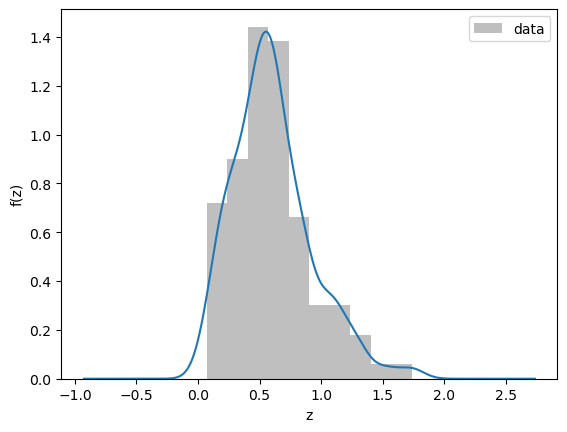

In [18]:
z_plot = np.linspace(z_vals.min() - 1, z_vals.max() + 1, 1000).reshape(-1, 1)
log_dens = kde.score_samples(z_plot)
dens = np.exp(log_dens)
plt.hist(z_sample, color='gray',alpha=0.5,label='data',density=True)

plt.plot(z_plot[:, 0], dens)
plt.xlabel('z')
plt.ylabel('f(z)')
plt.legend();

Text(0.5, 1.0, 'Cloned data')

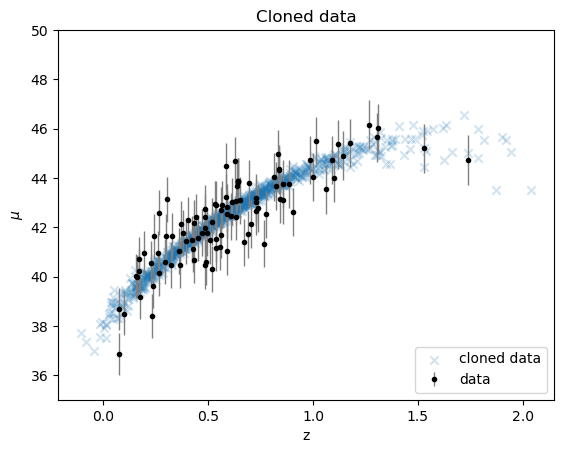

In [19]:
N = 1000
new_z_samples = kde.sample(N)

mu_gpr=[]
for z in np.squeeze(new_z_samples):    
    mu_fit, sigma = gps[np.argmin(etest)].predict([[z]], 
                           return_std=True)
    mu_gpr.append(np.random.normal(loc=mu_fit,scale=sigma))
    
    
plt.scatter(new_z_samples, mu_gpr, alpha=0.2, label='cloned data', marker='x')

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1, label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.ylim(35,50)
plt.title("Cloned data")

$\Lambda$CDM model
-

In [20]:
import emcee
import scipy.stats as scistats
import corner
import dynesty
from astropy.cosmology import LambdaCDM
import scipy

In [21]:
def model(z, H0, Om=1):
    cosmo_tmp = LambdaCDM(H0=H0, Om0=Om, Ode0=1-Om)
    return cosmo_tmp.distmod(z).value

In [22]:
data = np.array([z_sample, mu_sample, dmu])

H0min, H0max = 0,130
Ommin, Ommax = 0,1
ndim = 2



In [23]:
def loglike(theta):
    H0, Om = theta
    if Om<0:
        return -np.inf
    else:
        mu_model = model(z_sample, H0, Om)
    return np.sum(scistats.norm(loc=mu_model, scale=dmu).logpdf(mu_sample))


def ptform(u):
    x = np.array(u)  # copy u

    x[0] = scipy.stats.uniform(loc=H0min,scale=H0max-H0min).ppf(u[0])
    x[1] = scipy.stats.uniform(loc=Ommin,scale=Ommax-Ommin).ppf(u[1])

    return x

In [24]:
ndim = 2  # number of parameters in the model
nwalkers = 10  # number of MCMC walkers
nsteps = int(1e4)  # number of MCMC steps to take **for each walker**

starting_guesses = np.array([50,0.5]) + 1e-1* np.random.randn(nwalkers, ndim)
print(starting_guesses.shape)

(10, 2)


In [25]:
import warnings
with warnings.catch_warnings():
    # Those warnings come from regions where the likelihood is ~zero
    warnings.simplefilter("ignore", category=RuntimeWarning)

    # Define and run sampler
    sampler = dynesty.NestedSampler(loglike, ptform, ndim,nlive=300)
    sampler.run_nested()
    sresults = sampler.results

1332it [00:28, 47.46it/s, +300 | bound: 2 | nc: 1 | ncall: 11531 | eff(%): 14.531 | loglstar:   -inf < -132.814 <    inf | logz: -135.949 +/-  0.083 | dlogz:  0.001 >  0.309]


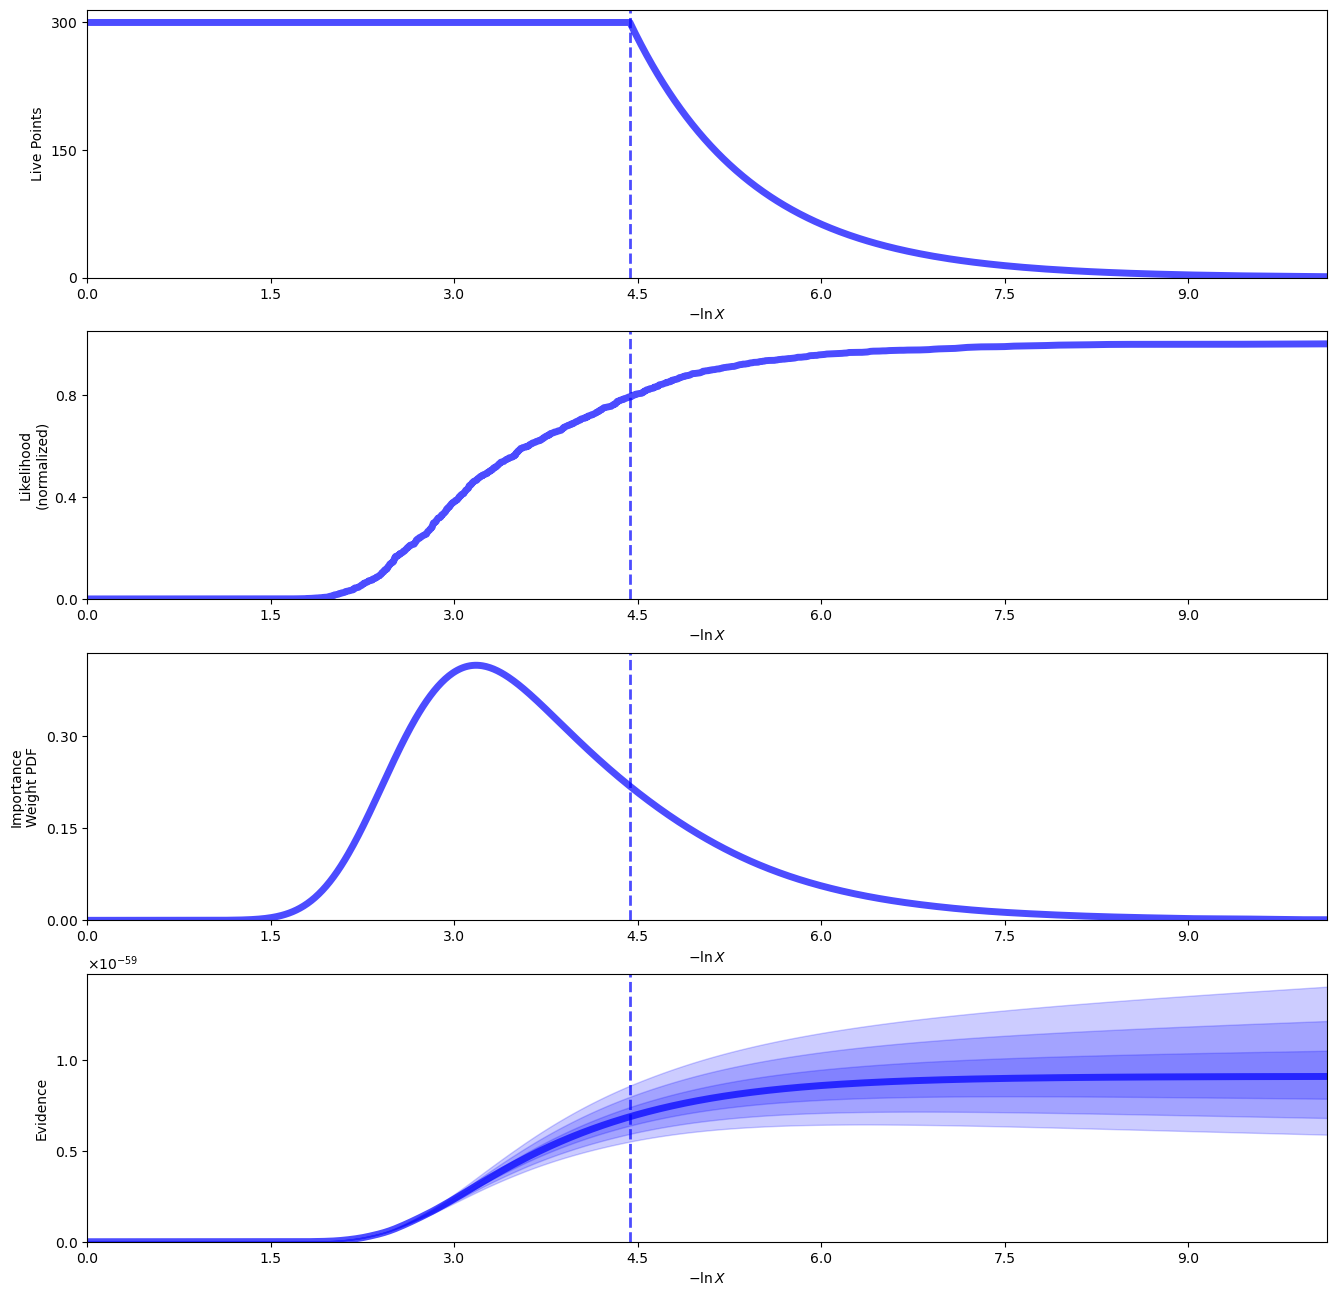

In [26]:
from dynesty import utils as dyfunc
from dynesty import plotting as dyplot

rfig, raxes = dyplot.runplot(sresults)

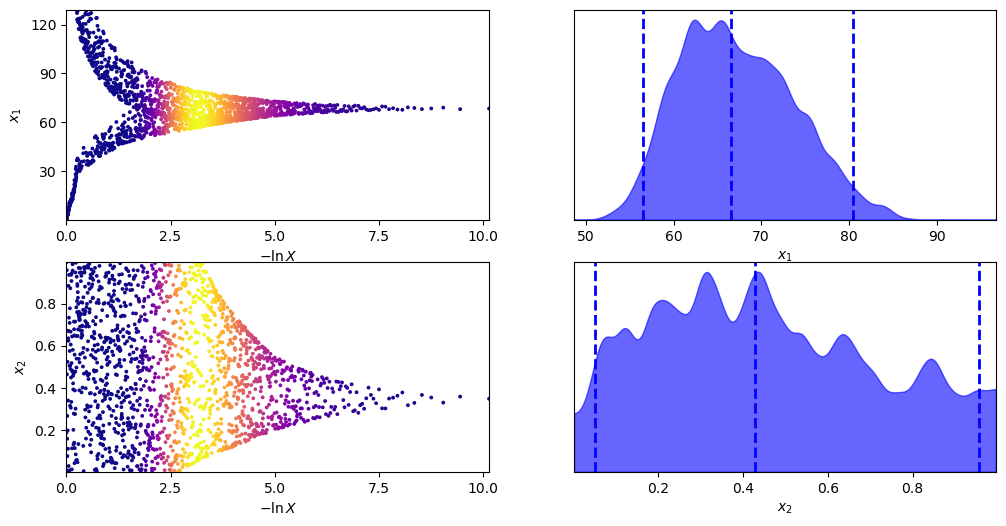

In [27]:
tfig, taxes = dyplot.traceplot(sresults)

In [28]:
samples = sresults.samples  # samples
weights = np.exp(sresults.logwt - sresults.logz[-1])  # normalized weights

evidence = sresults.logz[-1] #evidence
print("Bayesian evidence", np.exp(evidence))

# Compute 10%-90% quantiles.
quantiles = [dyfunc.quantile(samps, [0.16, 0.84], weights=weights)
             for samps in samples.T]
print('68% parameter credible regions are:\n ' + str(quantiles) + '\n')

# Compute weighted mean and covariance.
mean, cov = dyfunc.mean_and_cov(samples, weights)
print('Mean and covariance of parameters are: ' + str(mean) + '\n' + str(cov))


Bayesian evidence 9.083563176965908e-60
68% parameter credible regions are:
 [[60.543302362792225, 74.20410824935071], [0.17589463093559848, 0.766679274650042]]

Mean and covariance of parameters are: [67.22736442  0.4555973 ]
[[41.73517519 -1.46385889]
 [-1.46385889  0.06793479]]


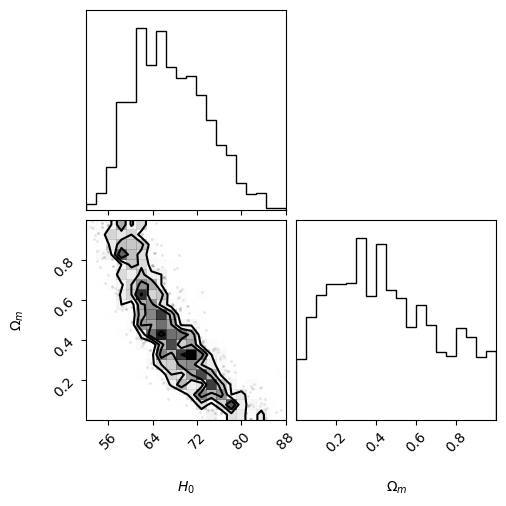

In [29]:
labels = ['$H_0$',r'$\Omega_m$']

samples_equal = dyfunc.resample_equal(samples, weights)
corner.corner(samples_equal,labels=labels);

In [30]:
labels = ['H_0','\Omega_m']

quantiles = [dyfunc.quantile(samps, [0.05, 0.5, 0.95], weights=weights)
             for samps in samples.T]
for q,l in zip(quantiles,labels):
    low,med,up=q
    print(l+"   "+str(med)+" +"+str(up-med)+" -"+str(med-low))

H_0   66.55957499659779 +12.002311426625724 -8.840786565729317
\Omega_m   0.4288760298919945 +0.4888490657840148 -0.356428101485349


In [31]:
from IPython.display import display, Math

for i in range(ndim):
    mcmc = dyfunc.quantile(samples[:,i], [0.05, 0.5, 0.95], weights=weights)
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.3f}_{{-{1:.3f}}}^{{{2:.3f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], labels[i])
    display(Math(txt))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [32]:
sresults.summary()

Summary
nlive: 300
niter: 1332
ncall: 11231
eff(%): 14.531
logz: -135.949 +/-  0.145


In [33]:
mean, cov = dyfunc.mean_and_cov(samples,weights)
cov

array([[41.73517519, -1.46385889],
       [-1.46385889,  0.06793479]])

In [34]:
model1_logz = sampler.results['logz'][-1]

CDM no DE
-

In [35]:
def model(z, H0):
    H0 = H0[0]
    Om = 1
    cosmo_tmp = LambdaCDM(H0=H0, Om0=Om, Ode0=1-Om)
    return cosmo_tmp.distmod(z).value

In [36]:
def loglike(theta):
    H0 = theta
    mu_model = model(z_sample, H0)
    return np.sum(scistats.norm(loc=mu_model, scale=dmu).logpdf(mu_sample))


def ptform(u):
    x = np.array(u)  # copy u

    x[0] = scipy.stats.uniform(loc=H0min,scale=H0max-H0min).ppf(u[0])

    return x

In [37]:
ndim = 1  # number of parameters in the model
nwalkers = 10  # number of MCMC walkers
nsteps = int(1e4)  # number of MCMC steps to take **for each walker**

starting_guesses = np.array([50]) + 1e-1* np.random.randn(nwalkers, ndim)
print(starting_guesses.shape)

(10, 1)


In [38]:

sampler = dynesty.NestedSampler(loglike, ptform, ndim,nlive=300)
sampler.run_nested()
sresults = sampler.results

1307it [00:22, 57.79it/s, +300 | bound: 2 | nc: 1 | ncall: 11675 | eff(%): 14.127 | loglstar:   -inf < -133.530 <    inf | logz: -136.561 +/-  0.080 | dlogz:  0.001 >  0.309]


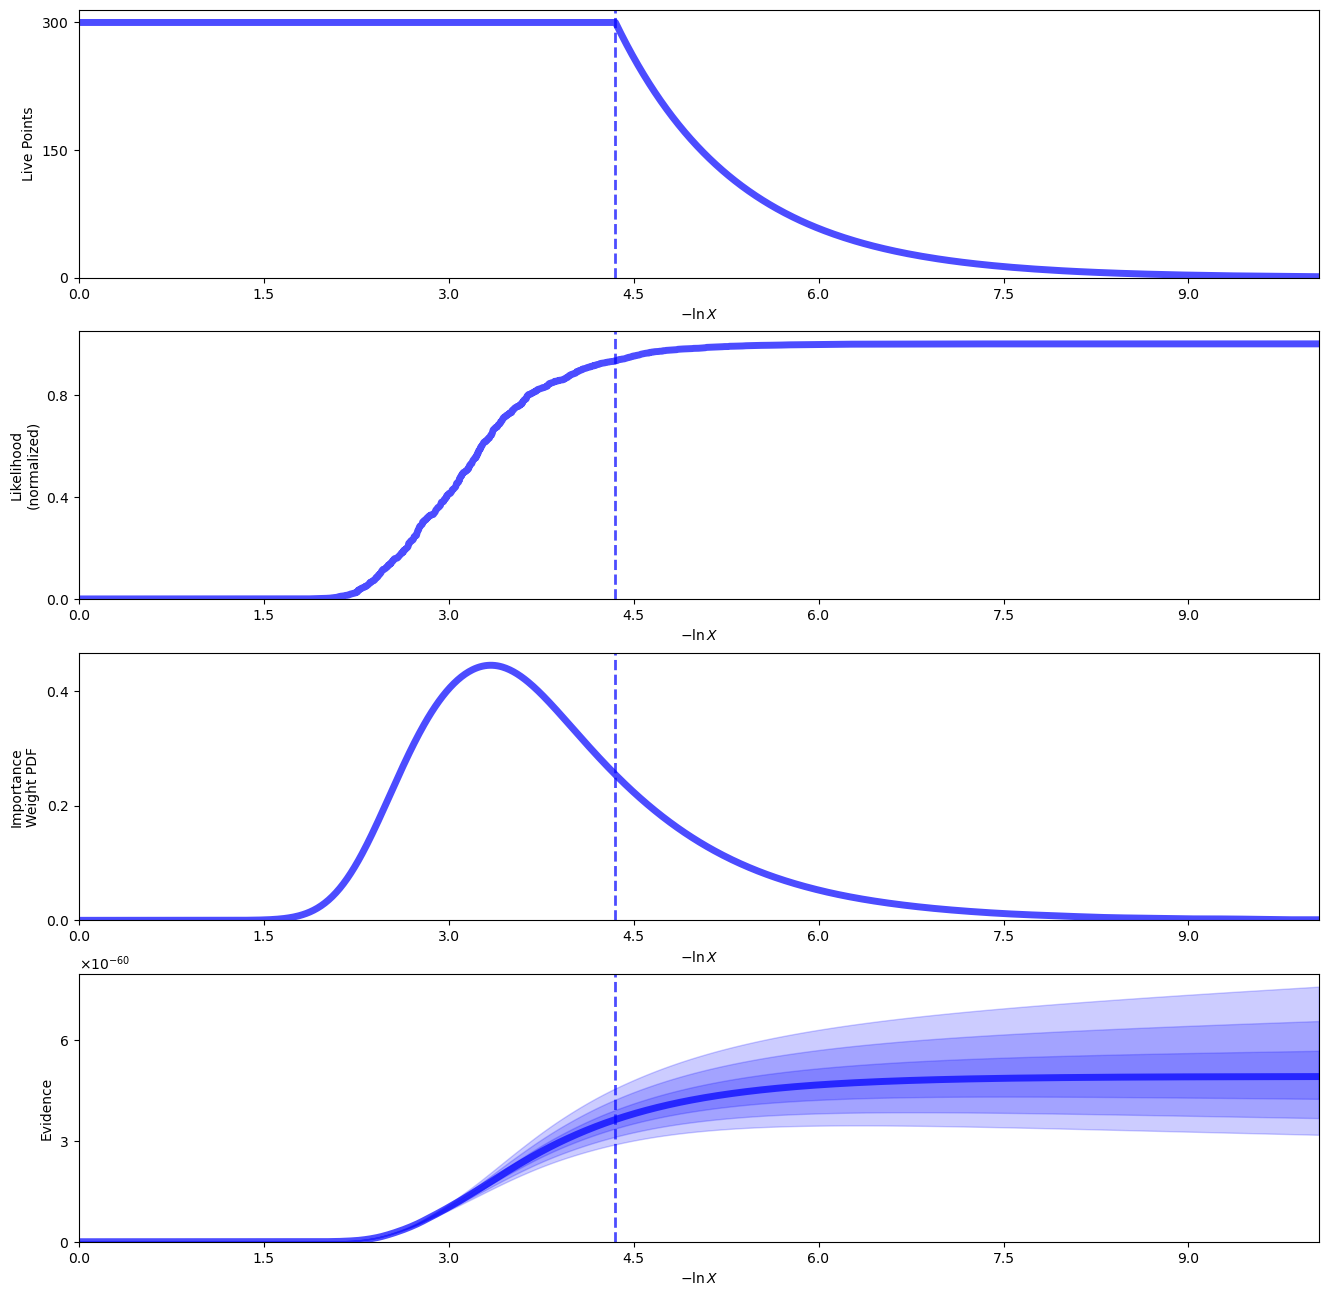

In [39]:
from dynesty import utils as dyfunc
from dynesty import plotting as dyplot

rfig, raxes = dyplot.runplot(sresults)

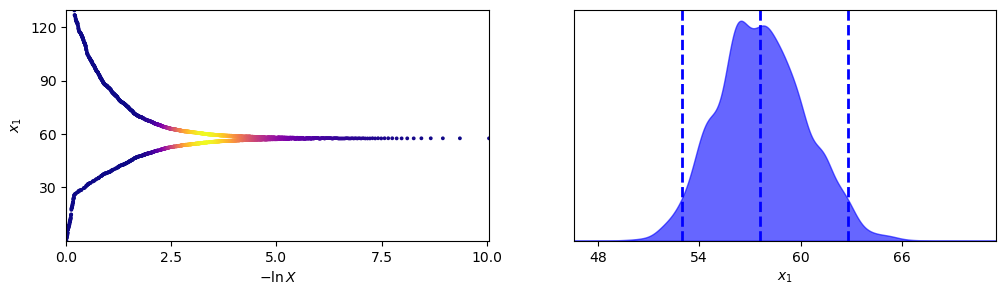

In [40]:
tfig, taxes = dyplot.traceplot(sresults)

In [41]:
samples = sresults.samples  # samples
weights = np.exp(sresults.logwt - sresults.logz[-1])  # normalized weights

evidence = sresults.logz[-1] #evidence
print("Bayesian evidence", np.exp(evidence))

# Compute 10%-90% quantiles.
quantiles = [dyfunc.quantile(samps, [0.16, 0.84], weights=weights)
             for samps in samples.T]
print('68% parameter credible regions are:\n ' + str(quantiles) + '\n')

# Compute weighted mean and covariance.
mean, cov = dyfunc.mean_and_cov(samples, weights)
print('Mean and covariance of parameters are: ' + str(mean) + '\n' + str(cov))


Bayesian evidence 4.9220123841695524e-60
68% parameter credible regions are:
 [[55.08724529977613, 60.27116970479205]]

Mean and covariance of parameters are: [57.68703347]
[[6.63532308]]


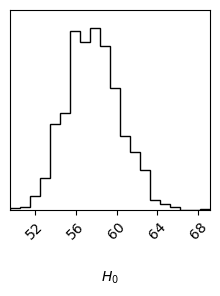

In [42]:
labels = ['$H_0$',r'$\Omega_m$']

samples_equal = dyfunc.resample_equal(samples, weights)
corner.corner(samples_equal,labels=labels);

In [43]:
labels = ['H_0','\Omega_m']

quantiles = [dyfunc.quantile(samps, [0.05, 0.5, 0.95], weights=weights)
             for samps in samples.T]
for q,l in zip(quantiles,labels):
    low,med,up=q
    print(l+"   "+str(med)+" +"+str(up-med)+" -"+str(med-low))

H_0   57.61960965475573 +4.489620328224433 -3.9112981090560837


In [44]:
from IPython.display import display, Math

for i in range(ndim):
    mcmc = dyfunc.quantile(samples[:,i], [0.05, 0.5, 0.95], weights=weights)
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.3f}_{{-{1:.3f}}}^{{{2:.3f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], labels[i])
    display(Math(txt))

<IPython.core.display.Math object>

In [45]:
sresults.summary()

Summary
nlive: 300
niter: 1307
ncall: 11375
eff(%): 14.127
logz: -136.561 +/-  0.145


In [46]:
model2_logz = sampler.results['logz'][-1]

In [47]:
no_prior = (model1_logz - model2_logz)
print('log(B12) = {:.4f}'.format(no_prior))

log(B12) = 0.6127


In [48]:
txt = "\mathrm{{{0}}} = {1:.3f}"
txt = txt.format(' log(B_{1-2})', no_prior)
display(Math(txt))
txt = "\mathrm{{{0}}} = {1:.3f}"
txt = txt.format('B_{1-2}', np.e**no_prior)
display(Math(txt))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

Jeffreys' scale: Berely worth mentioning